<a href="https://colab.research.google.com/github/laryferreira/ieeecisIA/blob/studies/CensusIncomePrediction_IEEE_LaryssaFerreira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Classificador de Renda - IEEE Computer Society
*   Laryssa de Oliveira Ferreira
*   222005386


## Descrição do desafio:

O conjunto de dados “Adult” (Census Income) reúne informações do censo dos EUA
de 1994, com 48.842 registros e 14 atributos demográficos e socioeconômicos. Seu
objetivo é construir um modelo de classificação binária para prever se a renda anual
de um indivíduo excede US$ 50.000.
Atributos
1. age (idade)
2. hours-per-week (horas trabalhadas por semana)
3. capital-gain (ganho de capital)
4. capital-loss (perda de capital)
5. fnlwgt (peso da amostra)
6. workclass (classe de trabalho)
7. education (nível de escolaridade)
8. marital-status (estado civil)
9. occupation (ocupação)
10. relationship (grau de parentesco)
11. race (raça)
12. sex (sexo)
13. native-country (país de origem)
14. income (“<=50K” ou “>50K”) (Variável alvo)

TAREFAS
1. Comparação de Modelos (OBRIGATÓRIA)
1. Treinar dois classificadores: Árvore de Decisão e Random Forest
1. Avaliar cada modelo usando:
• Acurácia
• Precisão
• Recall
• F1-score
1. Gerar:
• Matriz de confusão
• Gráfico de importância de atributos

**Atenção, a LLM Gemini Pro foi utilizada para me auxiliar na plotagem dos gráficos, ainda estou aprendendo!**

1.1 Importação das bibliotecas essenciais


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1.2 Mudar o nome das colunas originais para português (só pra me ajudar mesmo), processar o csv e remover a coluna 'fnlwgt' que indica o peso do censo, que não deve ser considerada na predição.


In [17]:
colunas_originais = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

colunas_em_portugues = [
    'idade', 'classe_de_trabalho', 'peso_final', 'escolaridade', 'anos_de_estudo',
    'estado_civil', 'ocupacao', 'grau_de_parentesco', 'raca', 'sexo',
    'ganho_de_capital', 'perda_de_capital', 'horas_por_semana', 'pais_de_origem', 'renda'
]

df = pd.read_csv('adult.csv', header=None, names=colunas_originais, na_values=' ?', skipinitialspace=True)
df.columns = colunas_em_portugues

df.drop('peso_final', axis=1, inplace=True)

2.1 Tratamento dos dados das colunas e separar dados de treinamento


In [18]:
#-------------- AQUI USEI IA --------------------#
# Converter colunas numéricas, transformando erros em NaN
colunas_numericas = ['idade', 'anos_de_estudo', 'ganho_de_capital', 'perda_de_capital', 'horas_por_semana']
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remover todas as linhas com valores ausentes
df.dropna(inplace=True)

#  Converter a variável alvo 'renda' para formato binário (0 ou 1)
df['renda'] = df['renda'].apply(lambda x: 1 if x == '>50K' else 0)

# 4. Converter colunas categóricas em variáveis dummy
colunas_categoricas = [
    'classe_de_trabalho', 'escolaridade', 'estado_civil', 'ocupacao',
    'grau_de_parentesco', 'raca', 'sexo', 'pais_de_origem'
]
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)
#Isso é um passo essencial na pré-processamento de dados para Machine Learning, principalmente com modelos que não lidam bem com texto/categorias diretamente (como regressão linear, árvores de decisão, redes neurais, etc.).
#-------------- AQUI USEI IA --------------------#

X = df.drop('renda', axis=1)
y = df['renda']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #30% dos dados para treinamento

2.2 Modelos de árvore de decisão e random forest


**Diferenças**

**Árvore de Decisão (Decision Tree)**

Uma Árvore de Decisão é um modelo único que aprende a tomar decisões com base em divisões sucessivas dos dados, formando uma estrutura semelhante a uma árvore com nós de decisão e folhas.

**Random Forest**

É um modelo de aprendizado de máquina do tipo ensemble que constrói várias árvores de decisão e combina seus resultados. Cada árvore é treinada com uma amostra aleatória dos dados e usa apenas um subconjunto das variáveis.


In [19]:
# Modelo 1: Árvore de Decisão

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

# Modelo 2: Random Forest

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)


# Resultados e Visualizações


print("## Resultados da Comparação de Modelos ##\n")
print("Métricas de Avaliação:")
results_df = pd.DataFrame({
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Árvore de Decisão': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})
print(results_df.to_string(index=False))

## Resultados da Comparação de Modelos ##

Métricas de Avaliação:
 Métrica  Árvore de Decisão  Random Forest
Acurácia           0.825980       0.849115
Precisão           0.641343       0.715423
  Recall           0.620513       0.614530
F1-Score           0.630756       0.661149


Analisando os resultados, **o Random Forest é o modelo superior e mais confiável para esta tarefa.**

Com maior acurácia geral (84.9%) e F1-Score (66.1%), seu principal benefício é a precisão mais alta, indicando que ele comete menos erros.

Embora a Árvore de Decisão tenha um recall superior, a precisão do Random Forest cria um modelo melhor.

3.1 Matrizes de confusão


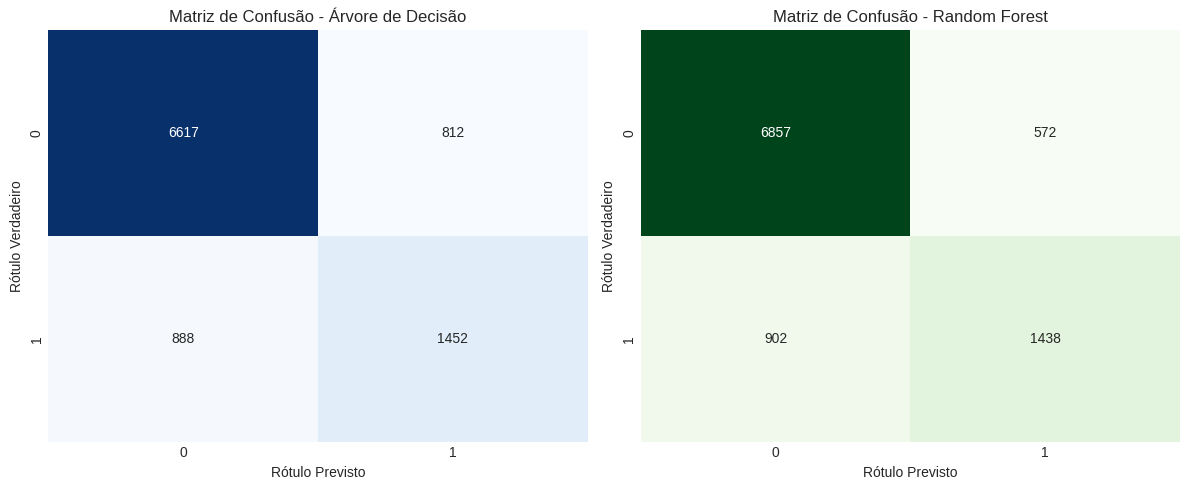

In [20]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.tight_layout()
plt.show()

As matrizes confirmam visualmente os resultados anteriores. O Random Forest comete menos erros do tipo Falso Positivo, tornando suas previsões positivas mais confiáveis e resultando em um desempenho geral superior, apesar de um número um pouco maior de Falsos Negativos.

3.2 Plotagem dos 7 atributos mais importantes em cada modelo de predição

<ipython-input-22-2164341730>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_dt, y=feature_importances_dt.index, palette='viridis')


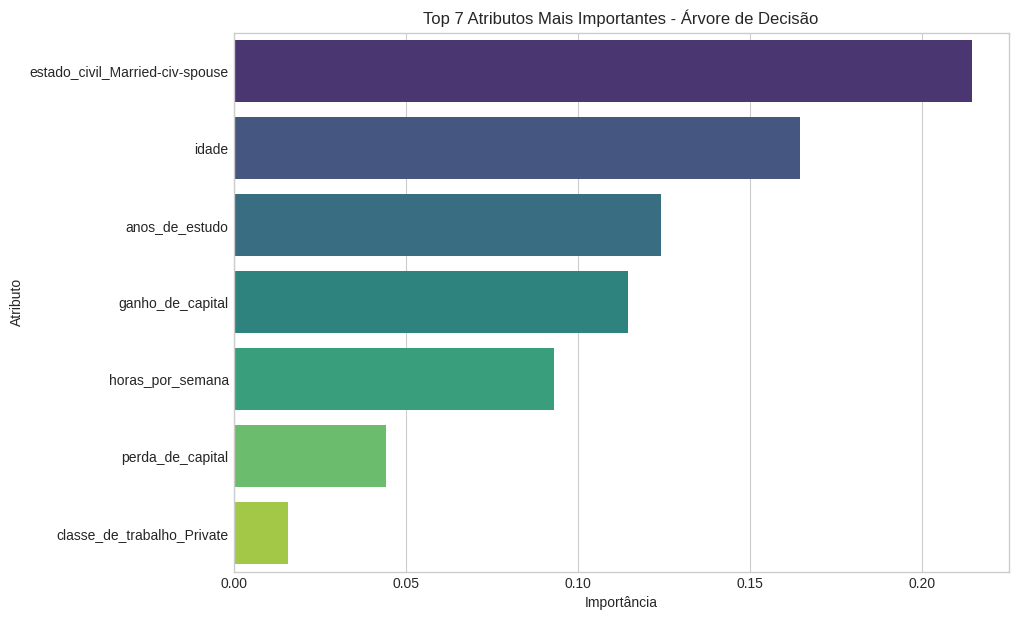

<ipython-input-22-2164341730>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_rf, y=feature_importances_rf.index, palette='plasma')


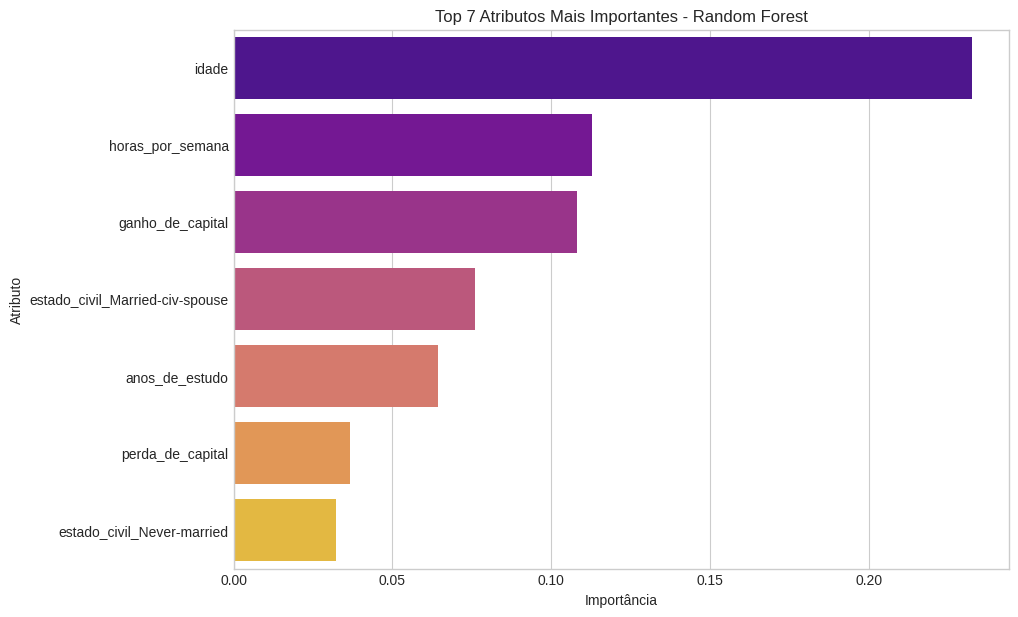

In [22]:
# Árvore de Decisão
importances_dt = dt_classifier.feature_importances_
feature_importances_dt = pd.Series(importances_dt, index=X.columns).sort_values(ascending=False).head(7)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances_dt, y=feature_importances_dt.index, palette='viridis')
plt.title('Top 7 Atributos Mais Importantes - Árvore de Decisão')
plt.xlabel('Importância')
plt.ylabel('Atributo')
plt.show()

# Random Forest
importances_rf = rf_classifier.feature_importances_
feature_importances_rf = pd.Series(importances_rf, index=X.columns).sort_values(ascending=False).head(7)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances_rf, y=feature_importances_rf.index, palette='plasma')
plt.title('Top 7 Atributos Mais Importantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Atributo')
plt.show()

**Conclusão**

Enquanto a Árvore de Decisão identifica o estado civil (estado_civil_Married-civ-spouse) como o fator mais importante, o Random Forest distribui a importância de forma mais equilibrada, destacando a idade como o atributo principal.

Apesar da diferença, ambos os modelos concordam que características como anos de estudo, ganho de capital e horas por semana são relevantes.

Essa diferença sugere que o Random Forest, ao várias árvores, oferece uma visão mais estável e generalizada da importância dos dados, evitando a dependência de um único atributo que pode ocorrer em uma árvore só.